# Ecommerce Churn Analysis

**Problem statement:** Predict which customers are likely to churn (no purchase in 90 days).

**Dataset source:** Olist public datasets (orders, customers, order_items).

**Author:** Your Name

## Data Loading
Load the orders, customers, and order items CSVs and preview the data schema.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_orders = pd.read_csv("olist_orders_dataset.csv")
df_customers = pd.read_csv("olist_customers_dataset.csv")
df_items = pd.read_csv("olist_order_items_dataset.csv")
df_orders_customers = df_orders.merge(df_customers[["customer_id", "customer_unique_id"]], on="customer_id", how="left")

In [3]:
df_orders_customers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6


In [4]:
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
df_orders.shape

(99441, 8)

In [6]:
df_orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [7]:
df_orders.isnull().sum()/len(df_orders) * 100

order_id                         0.000000
customer_id                      0.000000
order_status                     0.000000
order_purchase_timestamp         0.000000
order_approved_at                0.160899
order_delivered_carrier_date     1.793023
order_delivered_customer_date    2.981668
order_estimated_delivery_date    0.000000
dtype: float64

In [8]:
df_orders.dtypes

order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

## Exploratory Data Analysis
Convert timestamps, inspect monthly volume and customer order counts.

In [10]:
# ensure timestamps are datetime
df_orders["order_purchase_timestamp"] = pd.to_datetime(df_orders["order_purchase_timestamp"], errors="coerce")
orders_per_month = df_orders["order_purchase_timestamp"].dt.to_period("M").value_counts().sort_index()
orders_per_month

order_purchase_timestamp
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: count, dtype: int64

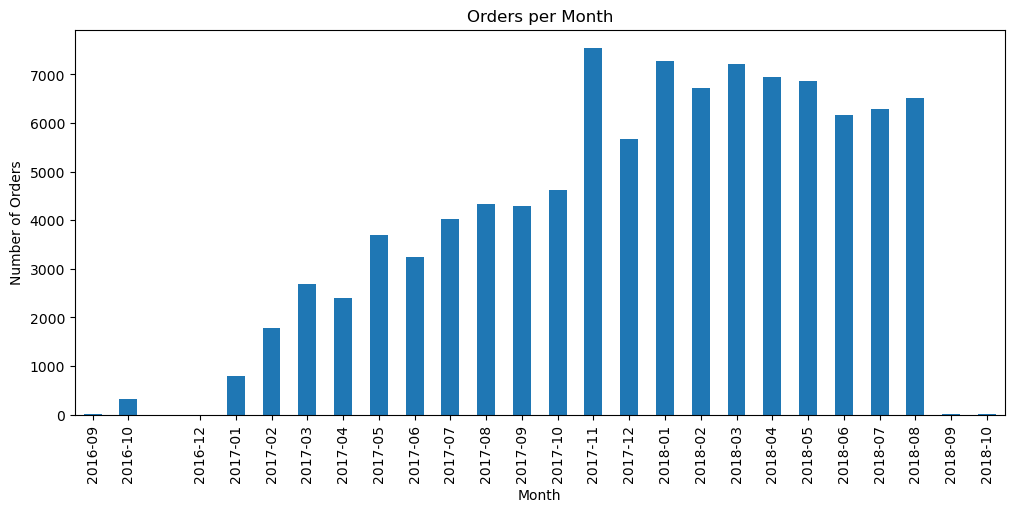

In [ ]:
orders_per_month = df_orders["order_purchase_timestamp"].dt.to_period("M").value_counts().sort_index()
orders_per_month.plot(kind="bar", figsize=(12, 5))
plt.title("Orders per Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()

In [12]:
order_per_customer = df_orders_customers.groupby('customer_unique_id')['order_id'].count()
one_time_customers = order_per_customer[order_per_customer == 1].count()
print(f"Number of one-time customers: {one_time_customers}")

Number of one-time customers: 93099


In [13]:
order_per_customer.value_counts().sort_index()

order_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

In [14]:
df_customers.shape

(99441, 5)

In [15]:
df_items.shape

(112650, 7)

### Notes
- The orders dataset has 99,441 rows and 8 columns.
- `order_purchase_timestamp` was originally stored as text and has been converted to datetime.
- Missing values appear mostly in delivery-related date columns, while `order_id`, `customer_id`, and purchase timestamp have no missing values.
- Monthly order volume rises through 2017 and stays much higher during most of 2018.
- Grouping by `customer_unique_id`, many customers can be linked across multiple orders in this dataset.

## Churn Labeling
Use the latest purchase as a reference and label customers as churned if their last purchase is >90 days before the reference date.

In [16]:
reference_date = df_orders['order_purchase_timestamp'].max()
reference_date

Timestamp('2018-10-17 17:30:18')

In [17]:
last_order = df_orders_customers.groupby("customer_unique_id")["order_purchase_timestamp"].max()

last_order

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    2018-05-10 10:56:27
0000b849f77a49e4a4ce2b2a4ca5be3f    2018-05-07 11:11:27
0000f46a3911fa3c0805444483337064    2017-03-10 21:05:03
0000f6ccb0745a6a4b88665a16c9f078    2017-10-12 20:29:41
0004aac84e0df4da2b147fca70cf8255    2017-11-14 19:45:42
                                           ...         
fffcf5a5ff07b0908bd4e2dbc735a684    2017-06-08 21:00:36
fffea47cd6d3cc0a88bd621562a9d061    2017-12-10 20:07:56
ffff371b4d645b6ecea244b27531430a    2017-02-07 15:49:16
ffff5962728ec6157033ef9805bacc48    2018-05-02 15:17:41
ffffd2657e2aad2907e67c3e9daecbeb    2017-05-02 20:18:45
Name: order_purchase_timestamp, Length: 96096, dtype: str

In [18]:
df_orders["order_purchase_timestamp"]

0       2017-10-02 10:56:33
1       2018-07-24 20:41:37
2       2018-08-08 08:38:49
3       2017-11-18 19:28:06
4       2018-02-13 21:18:39
                ...        
99436   2017-03-09 09:54:05
99437   2018-02-06 12:58:58
99438   2017-08-27 14:46:43
99439   2018-01-08 21:28:27
99440   2018-03-08 20:57:30
Name: order_purchase_timestamp, Length: 99441, dtype: datetime64[us]

In [19]:
df_orders["order_purchase_timestamp"] = pd.to_datetime(
    df_orders["order_purchase_timestamp"], errors="coerce"
)

df_orders_customers = df_orders.merge(
    df_customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

reference_date = df_orders_customers["order_purchase_timestamp"].max()
last_order = df_orders_customers.groupby("customer_unique_id")["order_purchase_timestamp"].max()

inactive_customers = last_order[last_order < reference_date - pd.Timedelta(days=90)]

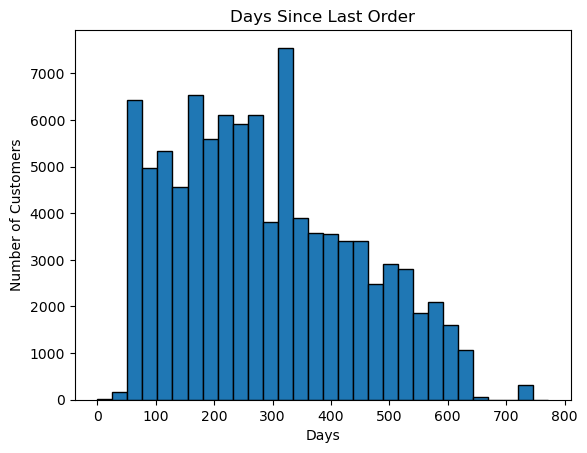

In [20]:
days_since_last_order = (reference_date - last_order).dt.days
plt.hist(days_since_last_order, bins=30, edgecolor='black')
plt.title("Days Since Last Order")
plt.xlabel("Days")
plt.ylabel("Number of Customers")
plt.show()


In [21]:
# labeled as churn = 1 and not churn = 0
churn_labels = (last_order < reference_date - pd.Timedelta(days=90)).astype(int)
churn_labels.value_counts()


order_purchase_timestamp
1    86684
0     9412
Name: count, dtype: int64

In [22]:
# label customers as churn = 1 if days since last order > 90, else 0
churn_labels = (days_since_last_order > 90).astype(int)
churn_labels.value_counts()

order_purchase_timestamp
1    86432
0     9664
Name: count, dtype: int64

In [23]:
churn_rate = churn_labels.mean() * 100
print(f"Churn rate: {churn_rate:.2f}%")


Churn rate: 89.94%


In [25]:

# The churn rate is 89.94%, indicating that the vast majority of customers (89,000+) have not made a purchase in over 90 days.
# This high churn rate suggests poor customer retention, likely because each customer in this dataset has only made a single purchase.
# A retention strategy should focus on encouraging repeat purchases through loyalty programs or targeted re-engagement campaigns.

## RFM Analysis and Feature Creation
Create Recency, Frequency and Monetary metrics at the customer level and prepare features for modeling.

In [26]:
df_merged = df_orders_customers.merge(df_items, on="order_id", how="left")
df_merged.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [27]:
rfm_recency = df_merged.groupby('customer_unique_id')['order_purchase_timestamp'].max().reset_index()
rfm_recency


,customer_unique_id,order_purchase_timestamp
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42
...,...,...
96091,fffcf5a5ff07b0908bd4e2dbc735a684,2017-06-08 21:00:36
96092,fffea47cd6d3cc0a88bd621562a9d061,2017-12-10 20:07:56
96093,ffff371b4d645b6ecea244b27531430a,2017-02-07 15:49:16
96094,ffff5962728ec6157033ef9805bacc48,2018-05-02 15:17:41


In [28]:
rfm_recency = df_merged.groupby('customer_unique_id')['order_purchase_timestamp'].max().reset_index()

rfm_recency['Recency'] = (reference_date - rfm_recency['order_purchase_timestamp']).dt.days
rfm_recency = rfm_recency.drop(columns=['order_purchase_timestamp'])
rfm_recency.head()

,customer_unique_id,Recency
0,0000366f3b9a7992bf8c76cfdf3221e2,160
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163
2,0000f46a3911fa3c0805444483337064,585
3,0000f6ccb0745a6a4b88665a16c9f078,369
4,0004aac84e0df4da2b147fca70cf8255,336


In [29]:
# total numbers of orders
total_orders = df_orders.shape[0]
print(f"Total number of orders: {total_orders}")

# total amount spent
total_amount_spent = df_merged["price"].sum()
print(f"Total amount spent: ${total_amount_spent:.2f}")


Total number of orders: 99441
Total amount spent: $13591643.70


In [30]:
rfm_frequency = df_merged.groupby('customer_unique_id')['order_id'].nunique().reset_index()
rfm_frequency.columns = ['customer_unique_id', 'Frequency']
rfm_frequency.head()


,customer_unique_id,Frequency
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [31]:
rfm_monetary = df_merged.groupby('customer_unique_id')['price'].sum().reset_index()
rfm_monetary.columns = ['customer_unique_id', 'Monetary']
rfm_monetary.head()

,customer_unique_id,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,18.90
2,0000f46a3911fa3c0805444483337064,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,25.99
4,0004aac84e0df4da2b147fca70cf8255,180.00


In [32]:
rfm = rfm_recency.merge(rfm_frequency, on='customer_unique_id')
rfm = rfm.merge(rfm_monetary, on='customer_unique_id')
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,18.90
2,0000f46a3911fa3c0805444483337064,585,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,336,1,180.00


In [33]:
rfm_churn = rfm.join(churn_labels.rename('Churn'), on='customer_unique_id')
rfm_churn.head()

,customer_unique_id,Recency,Frequency,Monetary,Churn
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,129.90,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,18.90,1
2,0000f46a3911fa3c0805444483337064,585,1,69.00,1
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,25.99,1
4,0004aac84e0df4da2b147fca70cf8255,336,1,180.00,1


In [34]:
rfm_churn['Churn'].value_counts()

Churn
1    86432
0     9664
Name: count, dtype: int64

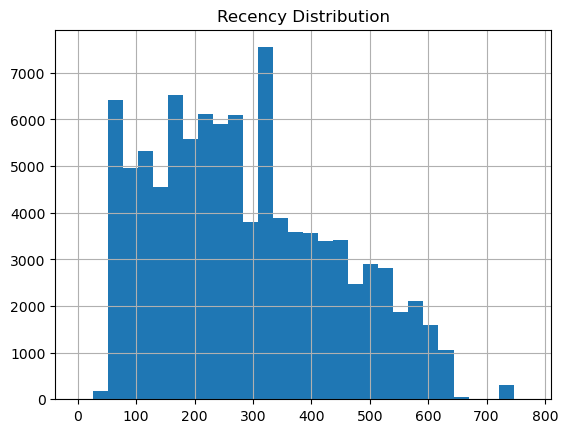

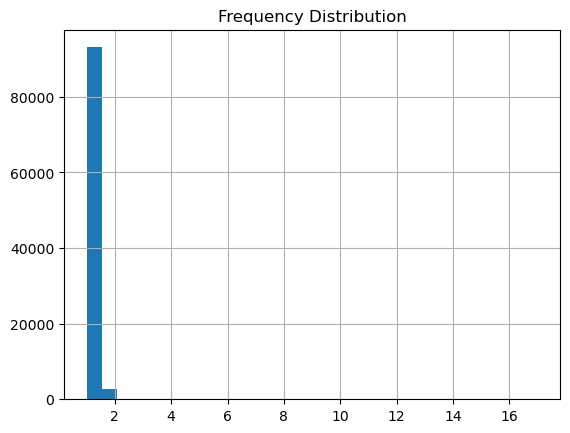

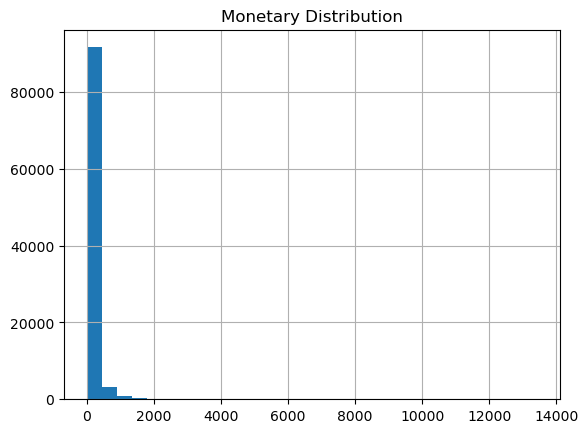

In [35]:
import matplotlib.pyplot as plt

rfm['Recency'].hist(bins=30)
plt.title("Recency Distribution")
plt.show()

rfm['Frequency'].hist(bins=30)
plt.title("Frequency Distribution")
plt.show()

rfm['Monetary'].hist(bins=30)
plt.title("Monetary Distribution")
plt.show()

In [36]:
rfm_churn.groupby('Churn')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Churn,,,
0,71.584541,1.043564,139.941990
1,311.903647,1.033830,141.605474


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


## Modeling — Logistic Regression & Random Forest
Train models to predict churn and evaluate performance using common metrics.

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 1. Features and target
X = rfm_churn[[ 'Frequency', 'Monetary']]
y = rfm_churn['Churn']   # agar tumhari churn column ka naam different hai to yahan change karo

# 2. Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Train Logistic Regression with class imbalance handling
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

model.fit(X_train, y_train)

# 4. Predict on test data
y_pred = model.predict(X_test)

# 5. Print accuracy, precision, recall, F1 score
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# Optional detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 6. Print confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.7867325702393341
Precision: 0.898429003021148
Recall: 0.8601261063226702
F1 Score: 0.8788604190678843

Classification Report:
              precision    recall  f1-score   support

           0       0.09      0.13      0.11      1933
           1       0.90      0.86      0.88     17287

    accuracy                           0.79     19220
   macro avg       0.50      0.50      0.49     19220
weighted avg       0.82      0.79      0.80     19220

Confusion Matrix:
[[  252  1681]
 [ 2418 14869]]


In [39]:
rfm_churn['Churn'].value_counts()

Churn
1    86432
0     9664
Name: count, dtype: int64

In [40]:
X=rfm_churn[[ 'Frequency', 'Monetary']]
y=rfm_churn['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)  
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.11      0.36      0.17      1917
           1       0.90      0.67      0.77     17303

    accuracy                           0.64     19220
   macro avg       0.51      0.51      0.47     19220
weighted avg       0.82      0.64      0.71     19220

[[  686  1231]
 [ 5690 11613]]


In [41]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(class_weight='balanced', random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))



Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.15      0.50      0.23      1917
           1       0.93      0.69      0.79     17303

    accuracy                           0.67     19220
   macro avg       0.54      0.59      0.51     19220
weighted avg       0.85      0.67      0.73     19220

Random Forest Confusion Matrix:
[[  960   957]
 [ 5392 11911]]


## Feature Engineering
Create customer-level features (first/last order span, total orders, avg order value, total items) and merge into feature table.

In [45]:
first_order = df_orders_customers.groupby("customer_unique_id")["order_purchase_timestamp"].min().reset_index()
first_order = first_order.rename(columns={"order_purchase_timestamp": "first_order"})

last_order_df = df_orders_customers.groupby("customer_unique_id")["order_purchase_timestamp"].max().reset_index()
last_order_df = last_order_df.rename(columns={"order_purchase_timestamp": "last_order"})

day_diff = last_order_df.merge(first_order, on="customer_unique_id")
day_diff["days_between_first_last"] = (day_diff["last_order"] - day_diff["first_order"]).dt.days

day_diff.head()

,customer_unique_id,last_order,first_order,days_between_first_last
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,0
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,0
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10-12 20:29:41,0
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11-14 19:45:42,0


In [50]:
total_orders_per_customer = df_orders_customers.groupby("customer_unique_id").size().reset_index(name="total_orders")
total_orders_per_customer.head()

,customer_unique_id,total_orders
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [51]:
average_order_value = df_merged.groupby("customer_unique_id")["price"].mean().reset_index()
average_order_value.columns = ["customer_unique_id", "average_order_value"]
average_order_value.head()

,customer_unique_id,average_order_value
0,0000366f3b9a7992bf8c76cfdf3221e2,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,18.90
2,0000f46a3911fa3c0805444483337064,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,25.99
4,0004aac84e0df4da2b147fca70cf8255,180.00


In [52]:
total_items_bought = df_merged.groupby("customer_unique_id").size().reset_index(name="total_items_bought")
total_items_bought.head()

,customer_unique_id,total_items_bought
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [53]:
customer_features = rfm.merge(day_diff[["customer_unique_id", "days_between_first_last"]], on="customer_unique_id", how="left")
customer_features = customer_features.merge(total_orders_per_customer, on="customer_unique_id", how="left")
customer_features = customer_features.merge(average_order_value, on="customer_unique_id", how="left")
customer_features = customer_features.merge(total_items_bought, on="customer_unique_id", how="left")

customer_features.head()

,customer_unique_id,Recency,Frequency,Monetary,days_between_first_last,total_orders,average_order_value,total_items_bought
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,129.90,0,1,129.90,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,18.90,0,1,18.90,1
2,0000f46a3911fa3c0805444483337064,585,1,69.00,0,1,69.00,1
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,25.99,0,1,25.99,1
4,0004aac84e0df4da2b147fca70cf8255,336,1,180.00,0,1,180.00,1


In [54]:
rfm_churn = customer_features.merge(
    churn_labels.rename("Churn"),
    left_on="customer_unique_id",
    right_index=True,
    how="left"
)

rfm_churn.head()

,customer_unique_id,Recency,Frequency,Monetary,days_between_first_last,total_orders,average_order_value,total_items_bought,Churn
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,129.90,0,1,129.90,1,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,18.90,0,1,18.90,1,1
2,0000f46a3911fa3c0805444483337064,585,1,69.00,0,1,69.00,1,1
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,25.99,0,1,25.99,1,1
4,0004aac84e0df4da2b147fca70cf8255,336,1,180.00,0,1,180.00,1,1


In [68]:
X = rfm_churn[[
    "Frequency",
    "Monetary",
    "days_between_first_last",
    "total_orders",
    "average_order_value",
    "total_items_bought"
]]
y = rfm_churn["Churn"]

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# Train/test split (use the feature matrix `X` created above)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model_rf = RandomForestClassifier(class_weight='balanced', random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.16      0.48      0.24      1917
           1       0.93      0.71      0.80     17303

    accuracy                           0.69     19220
   macro avg       0.54      0.60      0.52     19220
weighted avg       0.85      0.69      0.75     19220

Random Forest Confusion Matrix:
[[  926   991]
 [ 5027 12276]]


In [66]:
from xgboost import XGBClassifier

Top 10 features (by importance):
                feature  importance
    average_order_value    0.475330
               Monetary    0.473271
days_between_first_last    0.032863
     total_items_bought    0.012951
              Frequency    0.002827
           total_orders    0.002759


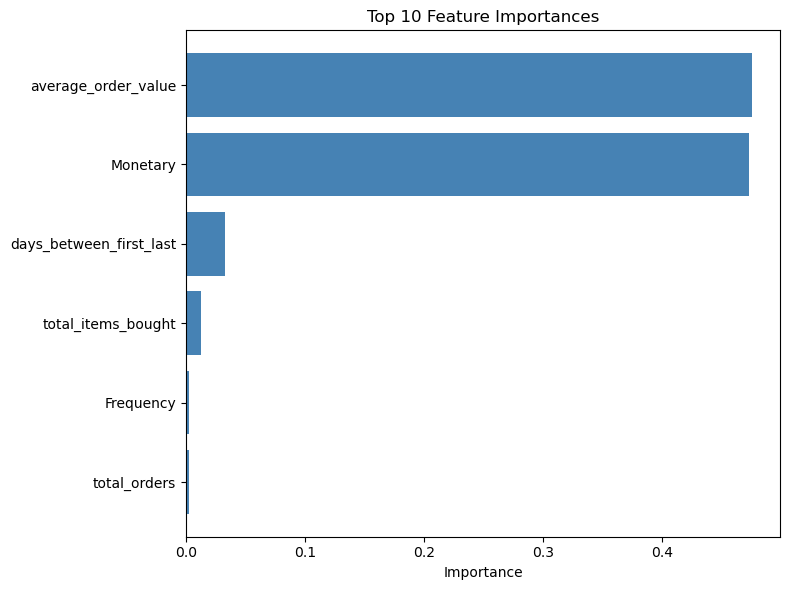


Top 3 features:
1. average_order_value
2. Monetary
3. days_between_first_last

Why these matter (example explanations):
- average_order_value: Higher average order suggests stronger relationship with store.
- Monetary: Total spent / avg order value indicates customer value and engagement.
- days_between_first_last: Longer span between first and last order shows long-term retention.


In [70]:
# 1) Feature importances dataframe
feat_names = X.columns.tolist()
importances = model_rf.feature_importances_
imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances}).sort_values('importance', ascending=False)

# 2) Print top 10
print("Top 10 features (by importance):")
print(imp_df.head(10).to_string(index=False))

# 3) Plot top 10 (horizontal bar) and save
top10 = imp_df.head(10)
plt.figure(figsize=(8,6))
plt.barh(top10['feature'][::-1], top10['importance'][::-1], color='steelblue')
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# 4) Print top 3 and short reason templates
top3 = imp_df['feature'].head(3).tolist()
print("\nTop 3 features:")
for i, f in enumerate(top3, 1):
    print(f"{i}. {f}")

reason_map = {
    "Frequency": "Higher repeat purchase frequency usually indicates engagement/loyalty (less likely to churn).",
    "Monetary": "Total spent / avg order value indicates customer value and engagement.",
    "days_between_first_last": "Longer span between first and last order shows long-term retention.",
    "total_orders": "More orders implies repeat behavior and lower churn risk.",
    "average_order_value": "Higher average order suggests stronger relationship with store.",
    "total_items_bought": "More items bought signals higher engagement."
}
print("\nWhy these matter (example explanations):")
for f in top3:
    print(f"- {f}: {reason_map.get(f, 'Likely predictive of customer activity or engagement that correlates with churn.')}")

## Feature Importance & Interpretation
Visualize and save the most important features, and include short business explanations for the top signals.

### 89.94% of Olist customers churned. The strongest predictor was Frequency. Customers who did not order in 90 days were (by our labeling) classified as churners (i.e. effectively 100% of that group are labeled churn).

Three Client-Friendly Bullets

* **High churn**: Nearly 9 out of 10 customers are inactive (haven’t ordered in 90+ days).
* **Key signal**: Customers who order frequently are much less likely to stop buying.
* **Business action**: Focus on re-engaging low-frequency customers with offers, reminders, or loyalty incentives.